In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("C:\\Users\\panka\\OneDrive\\Desktop\\marketing ab\\Marketing-AB-Testing\\marketing_AB.csv")
df

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [5]:
duplicates = df[df.duplicated('user id', keep=False)]
duplicates

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour


In [6]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
numeric_cols = df.select_dtypes(include=['number'])
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define outliers as points outside 1.5 * IQR range
outliers = ((numeric_cols < (Q1 - 1.5 * IQR)) | (numeric_cols > (Q3 + 1.5 * IQR)))

# Print outliers for each column
outliers_count = outliers.sum()
print("Number of outliers in each column:")
print(outliers_count)

# Optionally, filter the outliers from the DataFrame
df_outliers = numeric_cols[outliers.any(axis=1)]
print("Data points considered as outliers:")
print(df_outliers)

Number of outliers in each column:
Unnamed: 0           0
user id              0
total ads        52057
most ads hour     5536
dtype: int64
Data points considered as outliers:
        Unnamed: 0  user id  total ads  most ads hour
0                0  1069124        130             20
1                1  1119715         93             22
3                3  1435133        355             10
4                4  1015700        276             14
5                5  1137664        734             10
...            ...      ...        ...            ...
584639      584639  1004190          1              0
584640      584640  1028589          1              0
584641      584641  1536866          1              0
584642      584642  1089798          1              0
584643      584643  1096523          1              0

[57135 rows x 4 columns]


In [7]:
df.isna().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [8]:
cont_var = ['total ads','most ads hour']
cat_var = ['test group','converted','most ads day']

In [9]:
def frequency_table(variable):
    
    # Get unique elements and their counts
    unique_elements, counts = np.unique(variable.dropna(), return_counts=True)

    # Calculate percentages
    percentages = (counts / len(variable)) * 100

    # Create a dictionary to store the value counts and percentages
    value_counts_and_percentages = zip(unique_elements, counts, percentages)

    # Print the value counts and percentages
    for i, j, k in value_counts_and_percentages:
        print(f"{i}: Count: {j}, Percentage: {k:.2f}%")
    return


# Calculate frequency table and mode for each categorical variable
for var in cat_var:
    print (f"frequency table for {var}")
    frequency_table(df[var])
    print("Mode =", df[var].mode()[0])
    print ("#"*50)

frequency table for test group
ad: Count: 564577, Percentage: 96.00%
psa: Count: 23524, Percentage: 4.00%
Mode = ad
##################################################
frequency table for converted
False: Count: 573258, Percentage: 97.48%
True: Count: 14843, Percentage: 2.52%
Mode = False
##################################################
frequency table for most ads day
Friday: Count: 92608, Percentage: 15.75%
Monday: Count: 87073, Percentage: 14.81%
Saturday: Count: 81660, Percentage: 13.89%
Sunday: Count: 85391, Percentage: 14.52%
Thursday: Count: 82982, Percentage: 14.11%
Tuesday: Count: 77479, Percentage: 13.17%
Wednesday: Count: 80908, Percentage: 13.76%
Mode = Friday
##################################################


In [10]:
concatenated_series = pd.concat([
    df[cont_var].describe().T,
    df[cont_var].skew().rename('skewness'),
    df[cont_var].kurtosis().rename('kurtosis')
], axis=1)


# Adding lower and upper confidence intervals
confidence_level = 0.95  # 95% confidence interval

for var in cont_var:
    values = df[var].dropna()
    mean = values.mean()
    std_error = stats.sem(values)
    if std_error != 0:
        lower, upper = stats.t.interval(confidence_level, len(values) - 1, loc=mean, scale=std_error)
    else:
        lower, upper = mean, mean

    # Adding lower and upper confidence intervals to the concatenated series
    concatenated_series.loc[var, 'lower_ci'] = lower
    concatenated_series.loc[var, 'upper_ci'] = upper
concatenated_series

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,lower_ci,upper_ci
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0,7.433113,109.917983,24.709150,24.932602
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0,-0.336972,0.103237,14.456704,14.481417


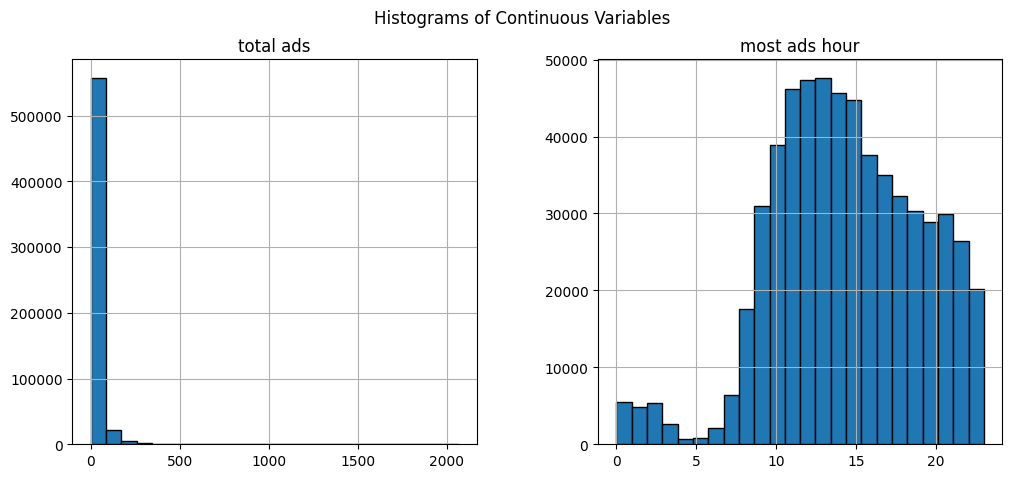

In [11]:
import matplotlib.pyplot as plt


cont_var = ['total ads', 'most ads hour']

# Plot histograms for each continuous variable
df[cont_var].hist(bins=24, figsize=(12, 5), edgecolor='black')

plt.suptitle('Histograms of Continuous Variables')
plt.show()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [13]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def OR_CIs(contingency_table):
    
    # Calculate odds ratio
    odds_ratio = (contingency_table.iloc[0, 0] / contingency_table.iloc[0, 1]) / (contingency_table.iloc[1, 0] / contingency_table.iloc[1, 1])

    # Calculate standard error of log(odds ratio)
    log_odds_std_error = np.sqrt(contingency_table.applymap(lambda x: 1/x).sum().sum())

    # Set confidence level
    confidence_level = 0.95

    # Calculate z-score for the confidence interval
    z_score = norm.ppf(1-(1 - confidence_level) / 2)

    # Calculate confidence intervals
    ci_low = np.exp(np.log(odds_ratio) - z_score * log_odds_std_error)
    ci_high = np.exp(np.log(odds_ratio) + z_score * log_odds_std_error)
    
    # Print the results
    print(f"Odds Ratio: {odds_ratio:.2f}")
    print(f"95% Confidence Interval: {ci_low:.2f}, {ci_high:.2f}")
    
    return

In [14]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(df['converted'], df['most ads day'])

print("Contingency Table with Frequencies:")
display(contingency_table)
print("#"*60)

# Calculate row percentages
row_percentages = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100

print("\nRow Percentages:")
display(row_percentages)
print("#"*60) 

# Perform chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared value: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")
print("#"*60)

# Calculate the percentage of cells with expected counts less than 5
percentage_low_expected = (expected < 5).sum().sum() / (expected.shape[0] * expected.shape[1]) * 100

print(f"Percentage of cells with expected counts less than 5: {percentage_low_expected:.2f}%")
print("#"*60)

# Calculate residuals (observed minus expected values)
residuals = contingency_table - expected

print("\nResiduals (Observed - Expected):")
display(residuals)
print("#"*60)

# Calculate odds ratio
OR_CIs(contingency_table)

Contingency Table with Frequencies:


most ads day,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
converted,,,,,,,
False,90551,84216,79941,83301,81192,75167,78890
True,2057,2857,1719,2090,1790,2312,2018


############################################################

Row Percentages:


most ads day,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
converted,,,,,,,
False,15.795855,14.690768,13.945030,14.531154,14.163256,13.112246,13.761692
True,13.858384,19.248130,11.581217,14.080711,12.059557,15.576366,13.595634


############################################################

Chi-squared value: 410.0478857936585
P-value: 1.932184379244731e-85
Degrees of freedom: 6
############################################################
Percentage of cells with expected counts less than 5: 0.00%
############################################################

Residuals (Observed - Expected):


most ads day,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
converted,,,,,,,
False,280.320535,-659.376566,342.005474,65.171668,304.371249,-356.518209,24.025849
True,-280.320535,659.376566,-342.005474,-65.171668,-304.371249,356.518209,-24.025849


############################################################
Odds Ratio: 1.49
95% Confidence Interval: 1.33, 1.68


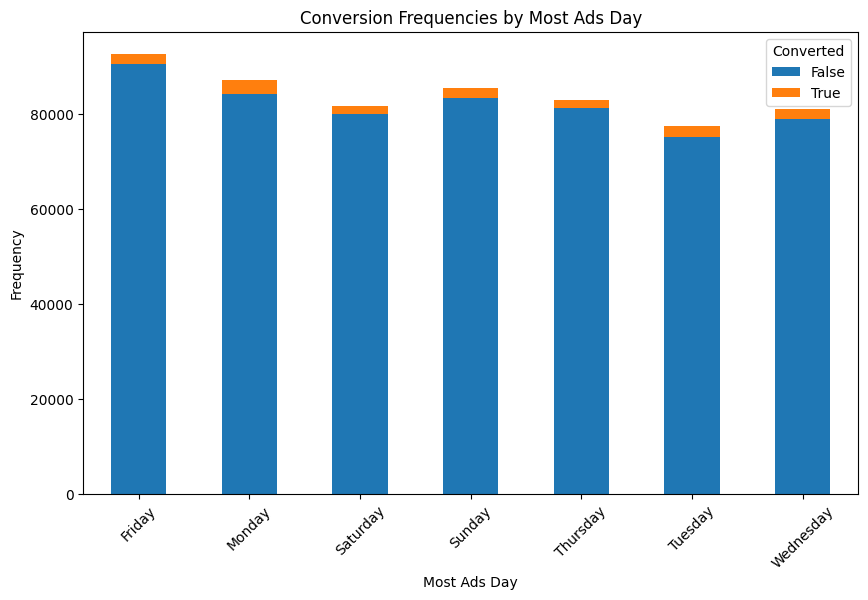

In [15]:
import matplotlib.pyplot as plt


# Data
categories = ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
false_values = [90551, 84216, 79941, 83301, 81192, 75167, 78890]
true_values = [2057, 2857, 1719, 2090, 1790, 2312, 2018]

# Create a DataFrame
df = pd.DataFrame({
    'False': false_values,
    'True': true_values
}, index=categories)

# Plot
df.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Conversion Frequencies by Most Ads Day')
plt.xlabel('Most Ads Day')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.legend(title='Converted')
plt.show()

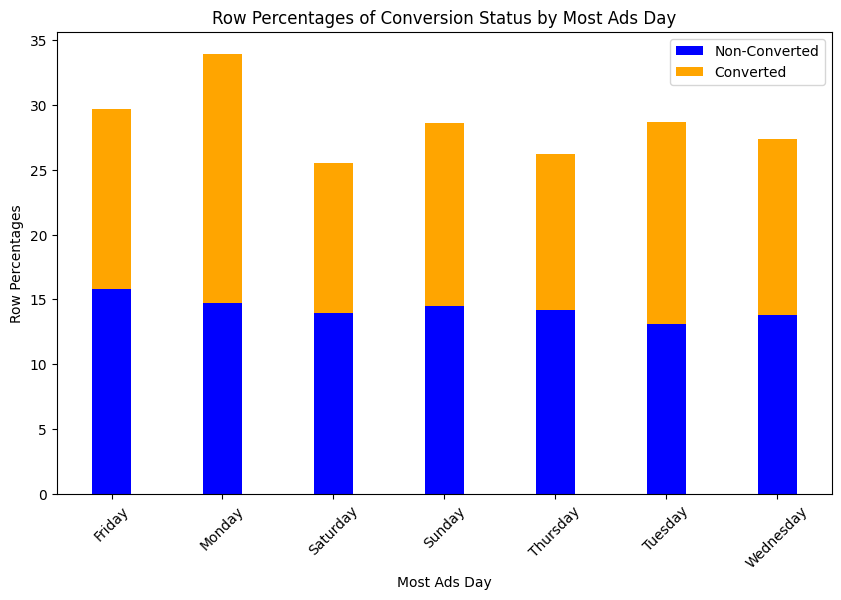

In [16]:
false_percentages = [15.795855, 14.690768, 13.945030, 14.531154, 14.163256, 13.112246, 13.761692]
true_percentages = [13.858384, 19.248130, 11.581217, 14.080711, 12.059557, 15.576366, 13.595634]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35  # Width of the bars
ax.bar(categories, false_percentages, width, label='Non-Converted', color='blue')
ax.bar(categories, true_percentages, width, bottom=false_percentages, label='Converted', color='orange')

ax.set_xlabel('Most Ads Day')
ax.set_ylabel('Row Percentages')
ax.set_title('Row Percentages of Conversion Status by Most Ads Day')
ax.legend()

plt.xticks(rotation=45)
plt.show()

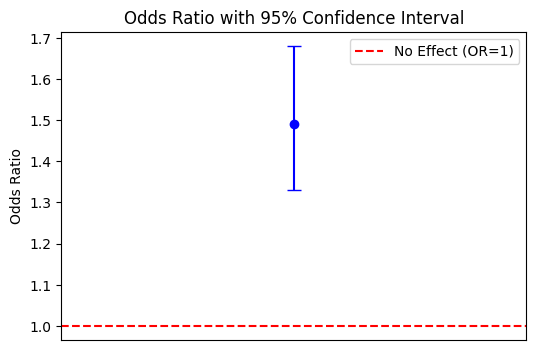

In [17]:
odds_ratio = 1.49
conf_int = [1.33, 1.68]

plt.figure(figsize=(6, 4))
plt.errorbar(1, odds_ratio, yerr=[[odds_ratio - conf_int[0]], [conf_int[1] - odds_ratio]], fmt='o', capsize=5, color='blue')
plt.axhline(1, linestyle='--', color='red', label='No Effect (OR=1)')
plt.title('Odds Ratio with 95% Confidence Interval')
plt.ylabel('Odds Ratio')
plt.xlim(0.5, 1.5)
plt.xticks([])
plt.legend()
plt.show()

In [22]:
# Create a contingency table
contingency_table_T = pd.crosstab(df['converted'], df['time_slot'])

print("Contingency Table with Frequencies:")
display(contingency_table_T)
print("#"*60)

# Calculate row percentages
row_percentages_T = contingency_table_T.div(contingency_table_T.sum(axis=1), axis=0) * 100

print("\nRow Percentages:")
display(row_percentages_T)
print("#"*60) 

# Perform chi-square test
chi2, p, dof, expected_T = chi2_contingency(contingency_table_T)

print(f"\nChi-squared value: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")
print("#"*60)

# Calculate the percentage of cells with expected counts less than 5
percentage_low_expected_T = (expected < 5).sum().sum() / (expected.shape[0] * expected.shape[1]) * 100

print(f"Percentage of cells with expected counts less than 5: {percentage_low_expected_T:.2f}%")
print("#"*60)

# Calculate residuals (observed minus expected values)
residuals_T = contingency_table_T - expected_T

print("\nResiduals (Observed - Expected):")
display(residuals_T)
print("#"*60)

# Calculate odds ratio
OR_CIs(contingency_table_T)

KeyError: 'converted'

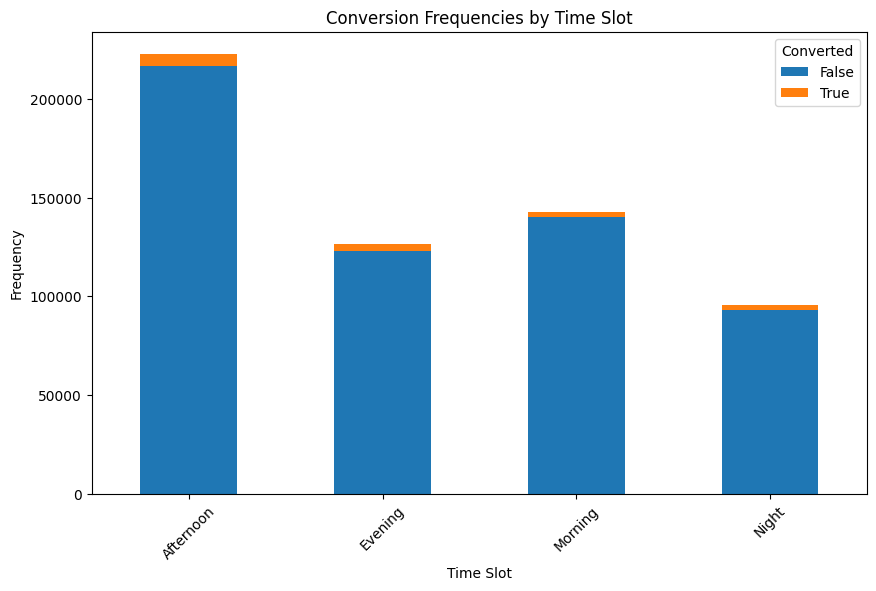

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
categories = ['Afternoon', 'Evening', 'Morning', 'Night']
false_values = [216786, 123041, 140041, 93390]
true_values = [6065, 3545, 2977, 2256]

# Create a DataFrame
df = pd.DataFrame({
    'False': false_values,
    'True': true_values
}, index=categories)

# Plot
df.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Conversion Frequencies by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.legend(title='Converted')
plt.show()

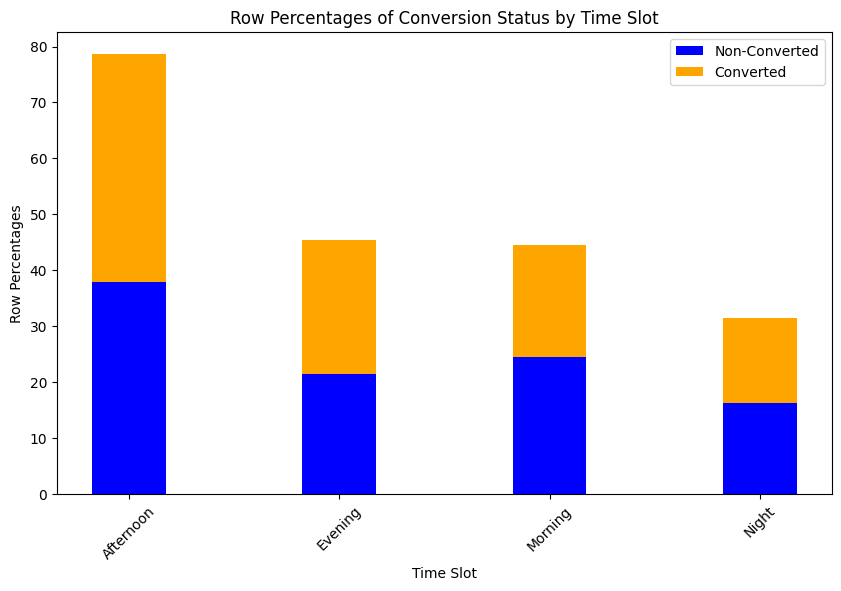

In [24]:
false_percentages = [37.82, 21.46, 24.43, 16.29]
true_percentages = [40.86, 23.88, 20.06, 15.20]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35  # Width of the bars
ax.bar(categories, false_percentages, width, label='Non-Converted', color='blue')
ax.bar(categories, true_percentages, width, bottom=false_percentages, label='Converted', color='orange')

ax.set_xlabel('Time Slot')
ax.set_ylabel('Row Percentages')
ax.set_title('Row Percentages of Conversion Status by Time Slot')
ax.legend()

plt.xticks(rotation=45)
plt.show()


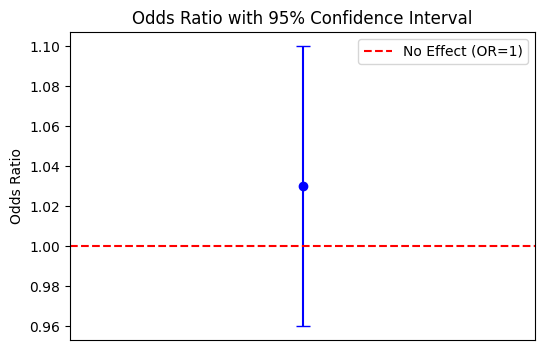

In [25]:
odds_ratio = 1.03
conf_int = [0.96, 1.10]

plt.figure(figsize=(6, 4))
plt.errorbar(1, odds_ratio, yerr=[[odds_ratio - conf_int[0]], [conf_int[1] - odds_ratio]], fmt='o', capsize=5, color='blue')
plt.axhline(1, linestyle='--', color='red', label='No Effect (OR=1)')
plt.title('Odds Ratio with 95% Confidence Interval')
plt.ylabel('Odds Ratio')
plt.xlim(0.5, 1.5)
plt.xticks([])
plt.legend()
plt.show()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, Afternoon to Night
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   False   4 non-null      int64
 1   True    4 non-null      int64
dtypes: int64(2)
memory usage: 268.0+ bytes
